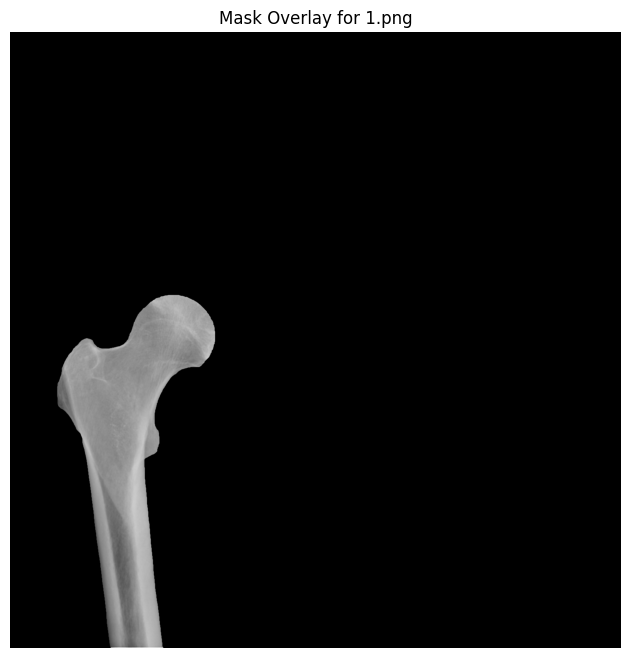

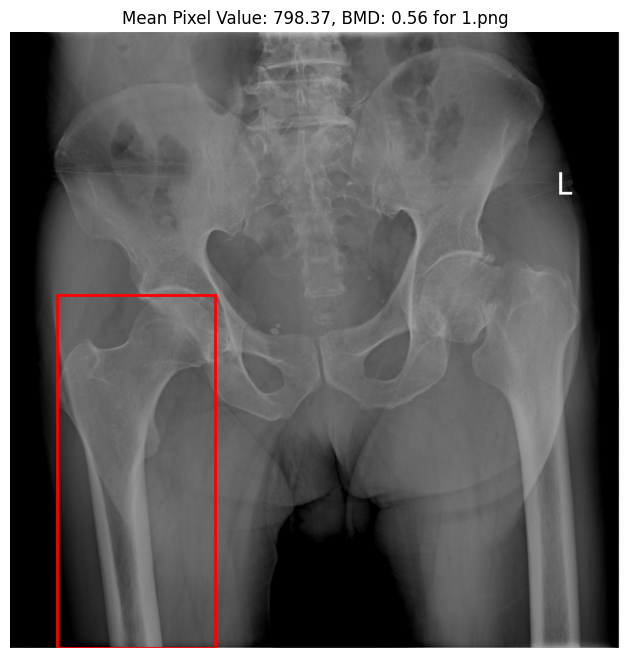

Mean pixel value in the mask 1.png: 798.37
BMD in the mask 1.png: 0.56


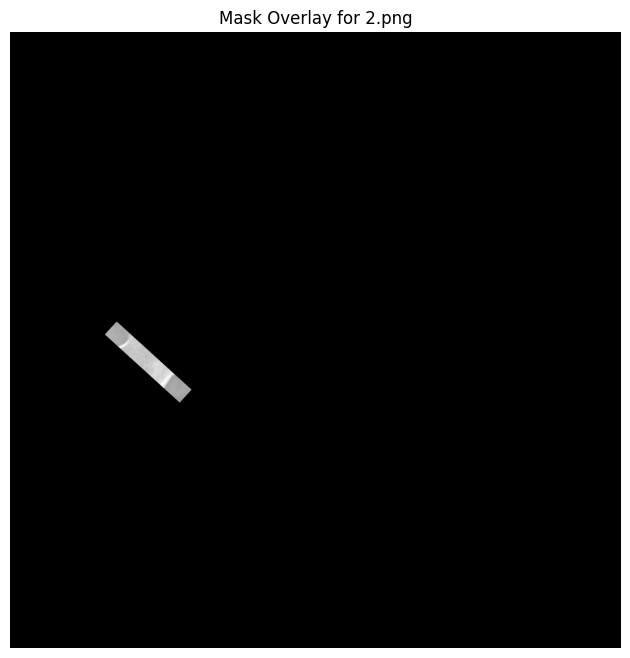

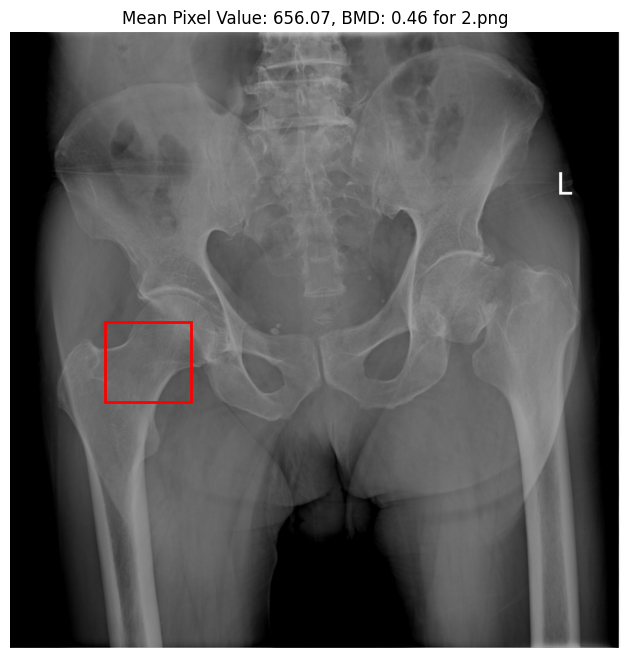

Mean pixel value in the mask 2.png: 656.07
BMD in the mask 2.png: 0.46


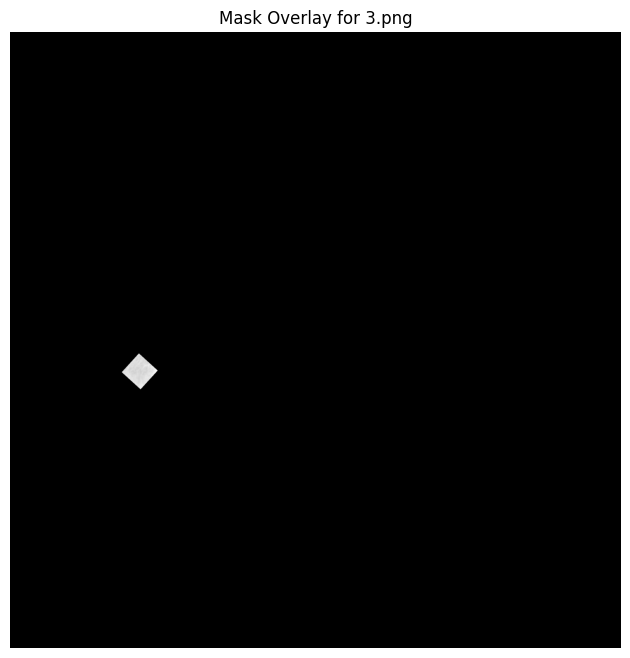

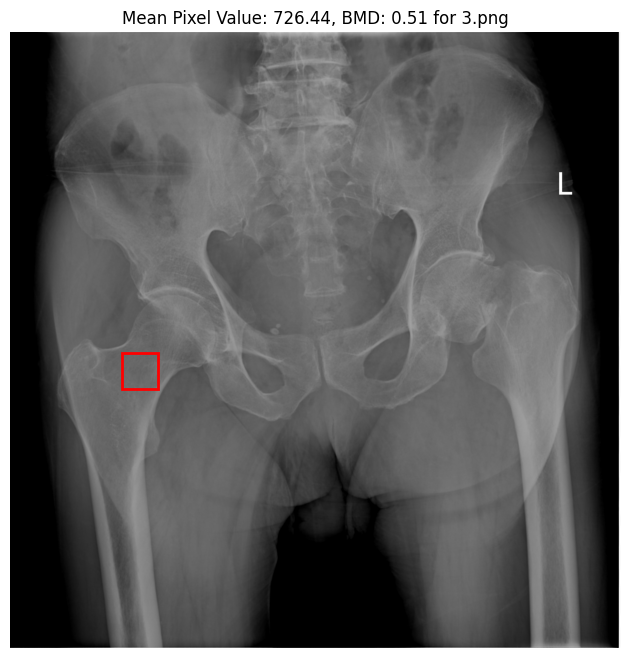

Mean pixel value in the mask 3.png: 726.44
BMD in the mask 3.png: 0.51


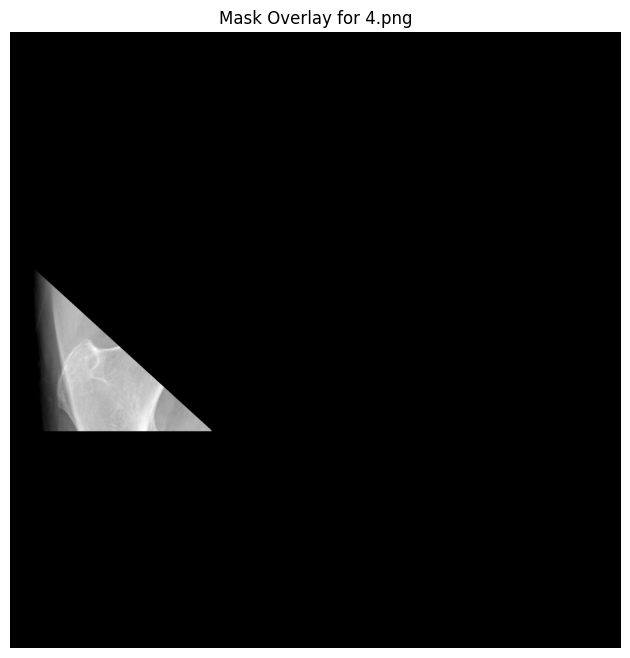

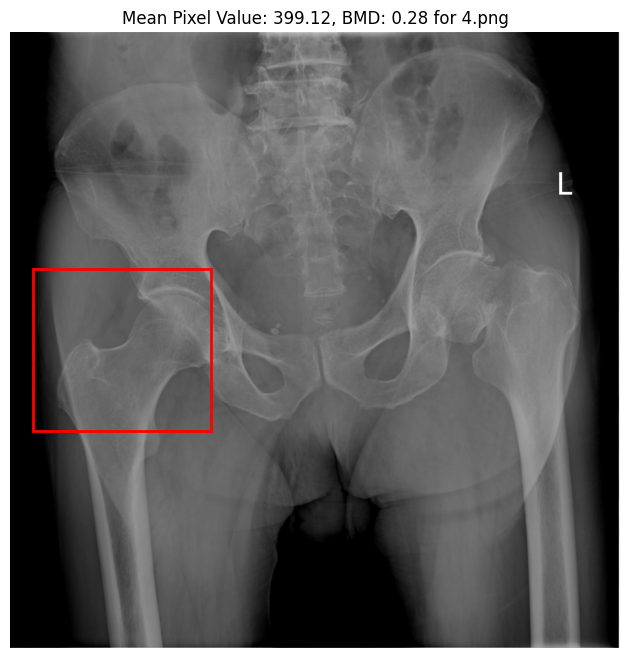

Mean pixel value in the mask 4.png: 399.12
BMD in the mask 4.png: 0.28


In [5]:
import os
import pydicom
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

# Load DICOM file
dicom_path = r"./00000005.dcm"
if not os.path.exists(dicom_path):
    print("DICOM file does not exist.")
    exit()

dicom_file = pydicom.dcmread(dicom_path)
image = dicom_file.pixel_array

# Mask paths
mask_paths = [f"./New Masks/{i+1}.png" for i in range(4)]

# Process each mask
for mask_path in mask_paths:
    if not os.path.exists(mask_path):
        print(f"Mask file {mask_path} does not exist. Skipping...")
        continue

    # Load and process the mask
    mask = Image.open(mask_path)
    mask_gray = mask.convert('L')  # Convert to grayscale
    mask_array = np.array(mask_gray)

    # Apply threshold to binarize the mask
    _, mask_binary = cv2.threshold(mask_array, 128, 255, cv2.THRESH_BINARY)
    mask_binary = mask_binary > 0  # Convert to boolean

    # Validate mask dimensions
    if mask_binary.shape != image.shape:
        print(f"Mask dimensions {mask_binary.shape} do not match DICOM image dimensions {image.shape}. Resizing mask...")
        mask_binary = cv2.resize(mask_binary.astype(np.uint8), (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask_binary = mask_binary > 0  # Re-binarize after resize

    # Create overlay with masked regions only
    overlay = np.zeros_like(image)
    overlay[mask_binary] = image[mask_binary]  # Only show pixels within the mask

    # Display the overlay
    plt.figure(figsize=(8, 8))
    plt.imshow(overlay, cmap='gray')
    plt.title(f"Mask Overlay for {mask_path.split('/')[-1]}")
    plt.axis('off')
    plt.show()

    # Calculate statistics for the masked region
    masked_pixels = image[mask_binary]
    if len(masked_pixels) == 0:
        print(f"Mask {mask_path.split('/')[-1]} has no valid pixels. Skipping...")
        continue

    masked_pixels = (masked_pixels + 1024) / 16 - 1024
    mean_pixel_value = masked_pixels.mean()
    bmd = 0.0007 * mean_pixel_value + 0.9216 - 0.920122

    # Find bounding box
    coords = np.where(mask_binary)
    if len(coords[0]) == 0:
        print(f"Mask {mask_path.split('/')[-1]} is empty. Skipping...")
        continue
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()

    # Plot with bounding box
    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap='gray')
    plt.title(f"Mean Pixel Value: {mean_pixel_value:.2f}, BMD: {bmd:.2f} for {mask_path.split('/')[-1]}")
    rect = Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, linewidth=2, edgecolor='red', facecolor='none')
    plt.gca().add_patch(rect)
    plt.axis('off')
    plt.show()

    print(f"Mean pixel value in the mask {mask_path.split('/')[-1]}: {mean_pixel_value:.2f}")
    print(f"BMD in the mask {mask_path.split('/')[-1]}: {bmd:.2f}")

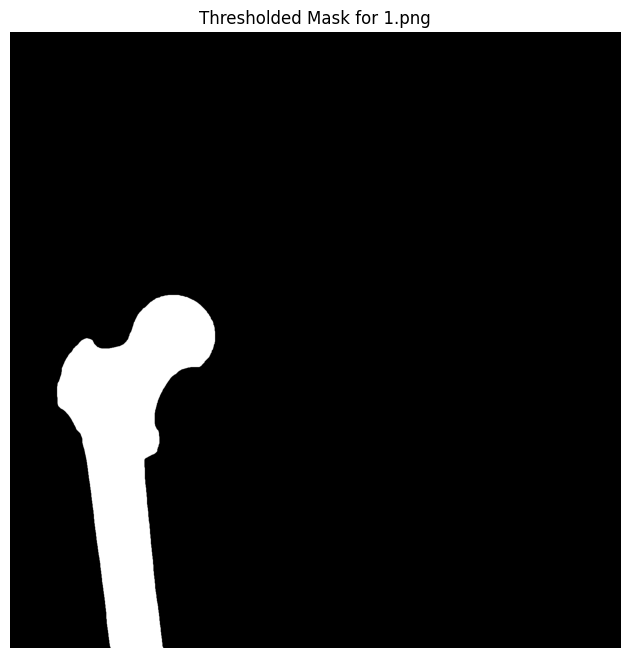

White pixel count in 1.png: 549838


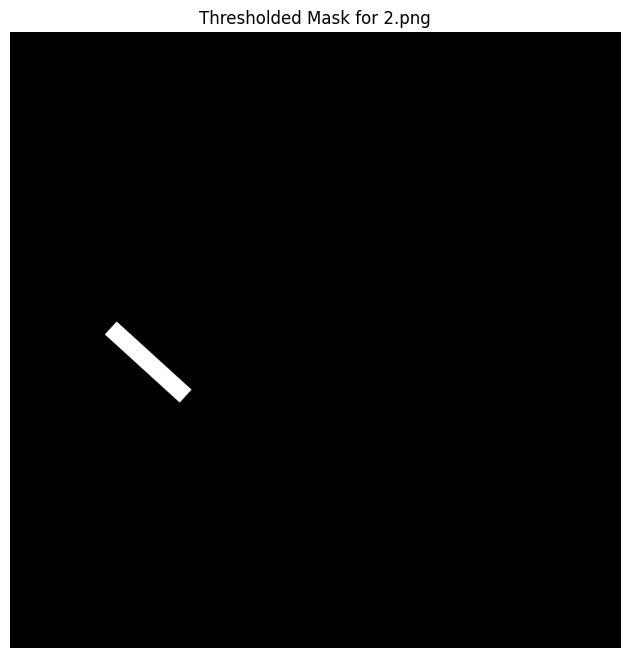

White pixel count in 2.png: 38842


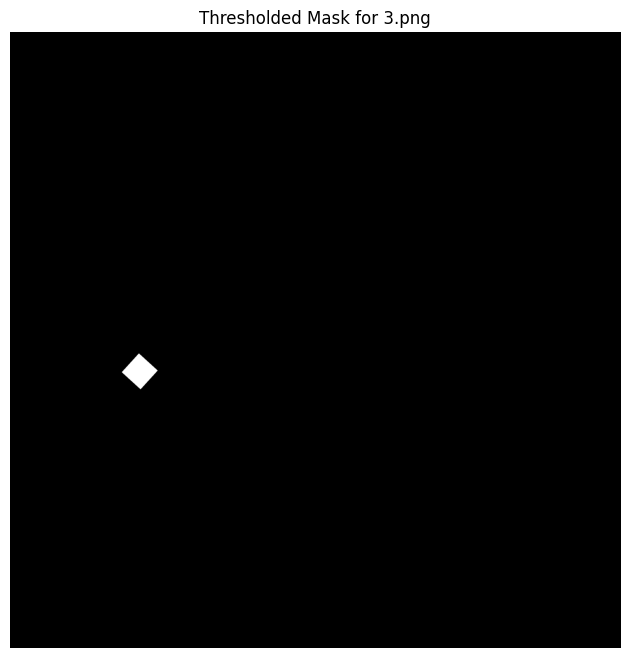

White pixel count in 3.png: 14169


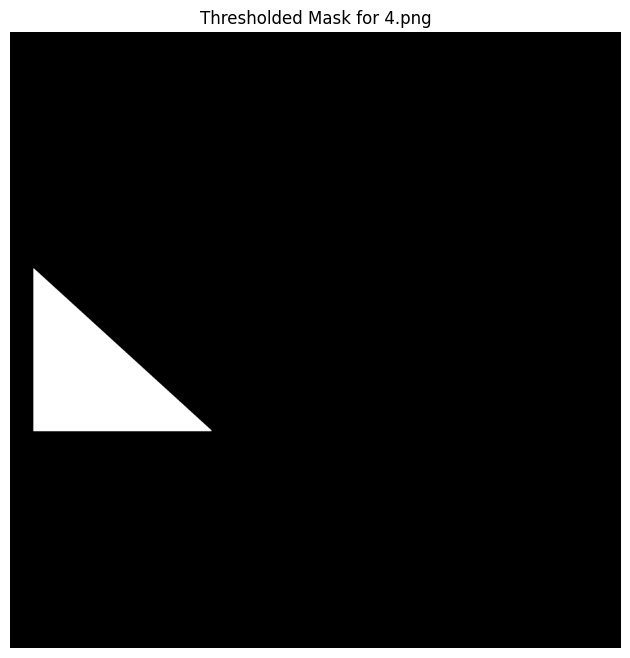

White pixel count in 4.png: 319703


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Mask paths
mask_paths = [f"./New Masks/{i+1}.png" for i in range(4)]

# Process each mask
for mask_path in mask_paths:
    if not os.path.exists(mask_path):
        print(f"Mask file {mask_path} does not exist. Skipping...")
        continue

    # Load and process the mask
    mask = Image.open(mask_path)
    mask_gray = mask.convert('L')  # Convert to grayscale
    mask_array = np.array(mask_gray)

    # Apply threshold to binarize the mask
    _, mask_binary = cv2.threshold(mask_array, 128, 255, cv2.THRESH_BINARY)  # Threshold at 1 for white pixels
    mask_binary = mask_binary > 0  # Convert to boolean for consistency

    # Display the thresholded mask
    plt.figure(figsize=(8, 8))
    plt.imshow(mask_binary, cmap='gray')
    plt.title(f"Thresholded Mask for {mask_path.split('/')[-1]}")
    plt.axis('off')
    plt.show()

    # Print some statistics for verification
    white_pixel_count = np.sum(mask_binary)
    print(f"White pixel count in {mask_path.split('/')[-1]}: {white_pixel_count}")